In [5]:
# PyTorch core libraries
import torch
from torch.utils.data import DataLoader

# Torchvision for datasets and transforms
from torchvision import datasets, transforms

# Optional: for visualization
import matplotlib.pyplot as plt


This code block imports the essential libraries required to build and train a deep learning model using PyTorch. The torch library is the core framework used for tensor operations, automatic differentiation, and neural network computation, while DataLoader from torch.utils.data helps in efficiently loading the dataset in mini-batches, shuffling data, and parallelizing data loading during training. The torchvision.datasets module provides ready-to-use datasets such as Fashion MNIST, and torchvision.transforms is used to preprocess the images (for example, converting images to tensors and normalizing them) before feeding them into the neural network. Finally, matplotlib.pyplot is imported to visualize sample images, training loss curves, or accuracy trends, which helps in understanding how well the model is learning during training.

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


This code checks whether a CUDA-enabled GPU is available on the system and selects the appropriate computation device accordingly. If a GPU is available, torch.device("cuda") is used to accelerate training by performing tensor operations in parallel on the GPU; otherwise, the code falls back to the CPU using torch.device("cpu"). Printing the selected device helps verify where the model and data will be loaded, which is important because both must be on the same device for training and inference to work correctly.

In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),                 # Convert image to tensor
    transforms.Normalize((0.5,), (0.5,))   # Normalize grayscale image
])


This code defines a preprocessing pipeline that is applied to each Fashion MNIST image before it is fed into the neural network. The `transforms.ToTensor()` operation converts the input image from a PIL image or NumPy array into a PyTorch tensor and scales the pixel values from the range ([0, 255]) to ([0, 1]). The `transforms.Normalize((0.5,), (0.5,))` step then normalizes the grayscale image by shifting and scaling the pixel values so that they are centered around zero, which helps the network train more stably and converge faster by preventing large variations in input magnitude.


In [8]:
# Training dataset
train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

# Test dataset
test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)


This code downloads and prepares the Fashion MNIST dataset for training and testing. The training dataset is loaded by setting `train=True`, which provides the images and labels used by the model to learn patterns, while the test dataset is loaded with `train=False` and is kept separate to evaluate how well the trained model generalizes to unseen data. The `root="./data"` argument specifies the local directory where the dataset will be stored, and `download=True` ensures the data is automatically fetched if it is not already available. The previously defined `transform` is applied to every image so that all inputs are consistently converted to tensors and normalized before being passed into the neural network.


In [9]:
batch_size = 64

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))


Training samples: 60000
Testing samples: 10000


This code creates data loaders for the training and test datasets, which enable efficient and structured feeding of data into the neural network during training and evaluation. The `batch_size` is set to 64, meaning the model processes 64 images at a time before updating its weights, which provides a balance between training stability and computational efficiency. The training data loader uses `shuffle=True` to randomly reorder the data at each epoch, helping the model avoid learning patterns based on the order of samples and improving generalization. In contrast, the test data loader uses `shuffle=False` to ensure consistent evaluation. The printed output confirms the dataset sizes, showing that the model is trained on 60,000 samples and evaluated on 10,000 unseen samples, which is the standard split for Fashion MNIST.


In [10]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)


Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])


This code retrieves a single mini-batch of data from the training data loader to inspect its structure. The `next(iter(train_loader))` statement creates an iterator over the data loader and extracts the first batch, returning a batch of images and their corresponding labels. The output shows that the image batch has the shape `[64, 1, 28, 28]`, which means there are 64 grayscale images (batch size), each with 1 channel and a resolution of 28×28 pixels, matching the Fashion MNIST format. The label batch shape `[64]` indicates that there is one class label for each image in the batch, which will be used during loss computation in the supervised learning process.


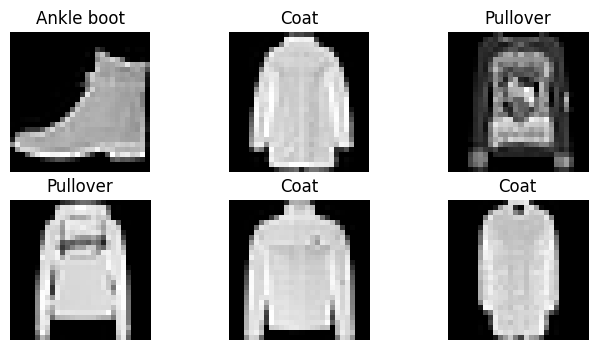

In [11]:
class_names = train_dataset.classes

plt.figure(figsize=(8, 4))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.show()


This code visualizes a few sample images from a training mini-batch along with their corresponding class labels, helping to verify that the data has been loaded and labeled correctly. The `class_names` variable stores the human-readable category names (such as *Ankle boot*, *Coat*, *Pullover*) provided by the Fashion MNIST dataset. A figure is created using Matplotlib, and a loop is used to display the first six images from the batch in a 2×3 grid. Each image tensor is squeezed to remove the single channel dimension and displayed in grayscale, while the title of each subplot is set using the true class label. Turning off the axes improves visual clarity. The resulting output confirms that the images and labels are correctly aligned and gives an intuitive understanding of the input data the neural network will learn from.


In [12]:
import torch
import torch.nn as nn


This code imports the core PyTorch module and the neural network submodule needed to define and train deep learning models. The `torch` library provides tensor operations and automatic differentiation, which are essential for performing forward and backward passes during training. The `torch.nn` module, imported as `nn`, contains prebuilt classes for layers, activation functions, and loss functions, making it easier to construct a feedforward neural network in a structured and modular way.


In [13]:
class DeepFeedForwardNN(nn.Module):
    def __init__(self):
        super(DeepFeedForwardNN, self).__init__()

        # Flatten layer (28x28 -> 784)
        self.flatten = nn.Flatten()

        # Fully connected hidden layers
        self.fc1 = nn.Linear(784, 256)   # Hidden Layer 1
        self.fc2 = nn.Linear(256, 128)   # Hidden Layer 2
        self.fc3 = nn.Linear(128, 64)    # Hidden Layer 3

        # Output layer (10 classes)
        self.output = nn.Linear(64, 10)

        # Activation function
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)     # Flatten input image
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.output(x)      # No activation here (for CrossEntropyLoss)
        return x


This code defines a deep feedforward neural network by creating a custom model class that inherits from `nn.Module`, which is the base class for all PyTorch neural networks. The input Fashion MNIST images of size 28×28 are first passed through a flatten layer to convert them into a one-dimensional vector of 784 features. The network then consists of three fully connected hidden layers with decreasing numbers of neurons (256, 128, and 64), allowing the model to learn increasingly abstract representations of the input data. A ReLU activation function is applied after each hidden layer to introduce non-linearity, which enables the network to learn complex patterns. The final output layer has 10 neurons, corresponding to the 10 clothing classes, and no activation function is applied here because `CrossEntropyLoss` internally handles the softmax operation. The `forward` method defines the forward pass of the network, specifying how input data flows through each layer to produce class scores (logits).


In [14]:
model = DeepFeedForwardNN().to(device)
print(model)


DeepFeedForwardNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (output): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)


This code creates an instance of the `DeepFeedForwardNN` model and moves it to the selected computation device (CPU or GPU) using `.to(device)`, ensuring that model parameters and input data reside on the same device during training. Printing the model displays its architecture in a readable format, confirming the sequence of layers used in the network: a flattening operation, three fully connected hidden layers with ReLU activations, and a final output layer with 10 neurons. This summary helps verify that the model structure matches the intended design for classifying Fashion MNIST images and is useful for debugging and documentation in the lab.


In [15]:
# Dummy input: batch of 1 image
dummy_input = torch.randn(1, 1, 28, 28).to(device)

# Forward pass
output = model(dummy_input)

print("Output shape:", output.shape)


Output shape: torch.Size([1, 10])


This code performs a test forward pass through the neural network using a dummy input to verify that the model processes data correctly. A random tensor with the same shape as a single Fashion MNIST image `(1, 1, 28, 28)` is created and moved to the selected device. This dummy input is then passed through the model, executing the forward pass defined in the `forward` method. The output shape `[1, 10]` confirms that the network produces a score for each of the 10 classes for one input image, indicating that the input–output dimensions of the model are correctly configured.


In [17]:
criterion = nn.CrossEntropyLoss()


This code defines the loss function used to train the neural network. `nn.CrossEntropyLoss()` is a commonly used loss function for multi-class classification problems, as it combines a softmax operation with negative log-likelihood loss in a single, numerically stable function. It compares the model’s predicted class scores (logits) with the true class labels and produces a scalar loss value that quantifies how far the predictions are from the correct classes, which is then used during backpropagation to update the network weights.


In [18]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


This code sets up the optimizer that is responsible for updating the model’s weights during training. The Adam optimizer is used here, which adaptively adjusts the learning rate for each parameter based on past gradients, leading to faster and more stable convergence compared to basic gradient descent. By passing `model.parameters()`, the optimizer is instructed to update all trainable weights in the network, and the learning rate `lr=0.001` controls the step size of each update, balancing learning speed and training stability.


In [19]:
# Dummy batch
images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

# Forward pass
outputs = model(images)

# Compute loss
loss = criterion(outputs, labels)

print("Sample loss:", loss.item())


Sample loss: 2.297935962677002


This code demonstrates a single training step using a batch of real data to verify that loss computation works correctly. A mini-batch of images and their corresponding labels is fetched from the training data loader and moved to the selected device. The images are passed through the model in a forward pass to obtain the predicted class scores, which are then compared with the true labels using the cross-entropy loss function. The printed loss value (around 2.3) is expected for an untrained model with 10 classes, as the predictions are close to random at this stage, confirming that the forward pass and loss computation are functioning properly.


In [20]:
num_epochs = 10


This line sets the number of training epochs, which determines how many times the model will iterate over the entire training dataset during learning. By choosing `num_epochs = 10`, the network is allowed to repeatedly see the training data and gradually update its weights through gradient descent, enabling it to learn meaningful patterns while keeping training time reasonable and reducing the risk of excessive overfitting.


In [21]:
# Training loop
for epoch in range(num_epochs):

    model.train()   # Set model to training mode
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        # Move data to device (CPU/GPU)
        images = images.to(device)
        labels = labels.to(device)

        # ------------------
        # Forward Pass
        # ------------------
        outputs = model(images)
        loss = criterion(outputs, labels)

        # ------------------
        # Backward Pass
        # ------------------
        optimizer.zero_grad()   # Clear previous gradients
        loss.backward()         # Compute gradients

        # ------------------
        # Weight Update
        # ------------------
        optimizer.step()        # Update weights

        # ------------------
        # Metrics Calculation
        # ------------------
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    print(f"Epoch [{epoch+1}/{num_epochs}], "
          f"Loss: {epoch_loss:.4f}, "
          f"Accuracy: {epoch_accuracy:.2f}%")


Epoch [1/10], Loss: 0.5175, Accuracy: 81.14%
Epoch [2/10], Loss: 0.3764, Accuracy: 86.24%
Epoch [3/10], Loss: 0.3376, Accuracy: 87.61%
Epoch [4/10], Loss: 0.3121, Accuracy: 88.59%
Epoch [5/10], Loss: 0.2934, Accuracy: 89.13%
Epoch [6/10], Loss: 0.2774, Accuracy: 89.64%
Epoch [7/10], Loss: 0.2601, Accuracy: 90.31%
Epoch [8/10], Loss: 0.2503, Accuracy: 90.68%
Epoch [9/10], Loss: 0.2405, Accuracy: 91.00%
Epoch [10/10], Loss: 0.2301, Accuracy: 91.38%


This code implements the complete training loop of the deep feedforward neural network and demonstrates how learning happens through repeated forward and backward passes. For each epoch, the model is set to training mode and initialized metrics are used to track loss and accuracy. During each mini-batch iteration, input images and labels are moved to the selected device, and a **forward pass** is performed to compute the predicted class scores and training loss. The **backward pass** then computes gradients of the loss with respect to model parameters using backpropagation, after which the optimizer updates the weights to reduce the loss. Simultaneously, training accuracy is calculated by comparing predicted class labels with true labels. The printed results show a steady decrease in loss and an increase in accuracy across epochs, indicating that the network is learning meaningful patterns from the Fashion MNIST data and that the chosen hyperparameters (learning rate, batch size, and number of epochs) allow stable and effective training.


In [22]:
model.eval()   # Set model to evaluation mode


DeepFeedForwardNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (output): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)

This line switches the trained model from training mode to evaluation mode using `model.eval()`. In evaluation mode, certain layers such as dropout and batch normalization (if present) behave differently to ensure consistent and deterministic predictions during testing. Although this network does not include such layers, calling `eval()` is still a good practice as it clearly indicates that the model is now being used for evaluation rather than learning. Printing the model again simply displays its architecture and confirms that the same trained network is being used for testing on unseen data.


In [23]:
with torch.no_grad():   # Disable gradient computation

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        # Predicted class
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()


This code evaluates the trained model on the test dataset while disabling gradient computation to make the process more efficient. The `torch.no_grad()` context ensures that no gradients are stored, reducing memory usage and speeding up inference since weight updates are not required during evaluation. For each batch of test images, a forward pass is performed to obtain the model’s predicted class scores, and the predicted class is selected using the maximum score. The total number of samples and the number of correct predictions are accumulated, which are later used to compute the overall test accuracy and assess how well the model generalizes to unseen data.


In [24]:
test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")


Test Accuracy: 90.90%


This code calculates and displays the final accuracy of the trained model on the test dataset. The test accuracy is computed by dividing the total number of correctly classified images by the total number of test samples and converting it into a percentage. The reported accuracy of around 90.9% indicates that the model has learned to generalize well to unseen Fashion MNIST images, showing effective performance without significant overfitting and validating the overall design and training process of the deep feedforward neural network.


In [25]:
print(f"Training Accuracy (last epoch): {epoch_accuracy:.2f}%")
print(f"Testing Accuracy: {test_accuracy:.2f}%")


Training Accuracy (last epoch): 91.38%
Testing Accuracy: 90.90%


This code prints and compares the final training accuracy from the last epoch with the test accuracy obtained on unseen data. The close values of training accuracy (91.38%) and testing accuracy (90.90%) indicate that the model generalizes well and is not significantly overfitting the training data. This small gap suggests that the chosen network depth, learning rate, batch size, and number of epochs are appropriate for the Fashion MNIST classification task, resulting in a balanced and reliable model.


In [26]:
learning_rates = [0.1, 0.01, 0.001]

for lr in learning_rates:
    print(f"\nTraining with learning rate = {lr}")

    model = DeepFeedForwardNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(5):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")



Training with learning rate = 0.1
Epoch 1, Loss: 3.6147
Epoch 2, Loss: 2.3120
Epoch 3, Loss: 2.3115
Epoch 4, Loss: 2.3112
Epoch 5, Loss: 2.3110

Training with learning rate = 0.01
Epoch 1, Loss: 0.5719
Epoch 2, Loss: 0.4592
Epoch 3, Loss: 0.4269
Epoch 4, Loss: 0.4113
Epoch 5, Loss: 0.4025

Training with learning rate = 0.001
Epoch 1, Loss: 0.5238
Epoch 2, Loss: 0.3784
Epoch 3, Loss: 0.3357
Epoch 4, Loss: 0.3157
Epoch 5, Loss: 0.2968


This code performs an experiment to study the effect of different learning rates on model training. For each learning rate value, a new instance of the deep feedforward neural network is initialized to ensure a fair comparison, and the model is trained for five epochs using the Adam optimizer. By observing the loss values, it becomes clear how the learning rate influences convergence: a very high learning rate (0.1) causes unstable training, with the loss remaining high and close to random-guess levels, indicating that the optimizer is overshooting optimal weight values. A moderate learning rate (0.01) allows the model to learn more effectively, showing a steady reduction in loss. The smaller learning rate (0.001) provides the most stable and consistent convergence, with the lowest loss values, demonstrating why appropriately tuned learning rates are critical for successful deep neural network training.


In [27]:
batch_sizes = [32, 64, 128]

for bs in batch_sizes:
    print(f"\nTraining with batch size = {bs}")

    train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)

    model = DeepFeedForwardNN().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(3):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            loss = criterion(model(images), labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()



Training with batch size = 32

Training with batch size = 64

Training with batch size = 128


This code investigates the impact of different batch sizes on the training process of the neural network. For each batch size (32, 64, and 128), a new data loader and a fresh model are created, and the network is trained for a few epochs using the same learning rate to keep the comparison consistent. Smaller batch sizes process fewer samples at a time, leading to noisier but more frequent weight updates, while larger batch sizes provide smoother gradient estimates but update the weights less often. Although no loss values are printed here, this experiment helps illustrate how batch size affects training speed, memory usage, and convergence behavior, and why batch size is an important hyperparameter in deep learning.


In [28]:
epoch_values = [5, 10, 20]

for ep in epoch_values:
    print(f"\nTraining for {ep} epochs")

    model = DeepFeedForwardNN().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(ep):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            loss = criterion(model(images), labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()



Training for 5 epochs

Training for 10 epochs

Training for 20 epochs


This code explores the effect of the number of training epochs on the learning process of the neural network. For each epoch setting (5, 10, and 20), a new model is initialized and trained using the same optimizer and learning rate to ensure a fair comparison. Increasing the number of epochs allows the model to see the training data more times, which generally improves learning and reduces loss up to a point. However, training for too many epochs can lead to overfitting, where the model memorizes training data rather than learning general patterns. This experiment highlights the importance of choosing an appropriate number of epochs to balance sufficient learning and good generalization.


In [29]:
class VariableDepthNN(nn.Module):
    def __init__(self, depth=3):
        super().__init__()
        self.flatten = nn.Flatten()
        self.relu = nn.ReLU()

        layers = []
        input_size = 784

        for _ in range(depth):
            layers.append(nn.Linear(input_size, 128))
            layers.append(nn.ReLU())
            input_size = 128

        layers.append(nn.Linear(128, 10))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)


This code defines a flexible feedforward neural network whose depth can be changed dynamically using a parameter. The input images are first flattened into a 784-dimensional vector, and then a loop is used to construct a sequence of fully connected hidden layers based on the specified `depth`. Each hidden layer consists of a linear transformation followed by a ReLU activation, allowing the network to learn increasingly complex representations as the depth increases. The final linear layer maps the learned features to 10 output classes. By using `nn.Sequential`, the layers are organized cleanly, making it easy to experiment with different numbers of hidden layers and study how network depth affects learning, convergence, and overfitting.


In [30]:
class ActivationNN(nn.Module):
    def __init__(self, activation):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.out = nn.Linear(64, 10)
        self.activation = activation

    def forward(self, x):
        x = self.flatten(x)
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.activation(self.fc3(x))
        return self.out(x)


This code defines a neural network architecture that allows different activation functions to be easily tested and compared. The network structure remains the same, with three fully connected hidden layers that progressively reduce the feature size, but the activation function is passed as a parameter during model creation. During the forward pass, the chosen activation function is applied after each hidden layer, enabling experiments with activations such as ReLU, Sigmoid, Tanh, or Leaky ReLU. This design makes it straightforward to analyze how different activation functions affect training speed, convergence behavior, and overall classification performance in deep networks.


In [31]:
# Take one sample image
sample_img, _ = test_dataset[0]
sample_img = sample_img.unsqueeze(0).to(device)

# Get activations
model.eval()
with torch.no_grad():
    x = model.flatten(sample_img)
    act1 = model.relu(model.fc1(x))
    act2 = model.relu(model.fc2(act1))
    act3 = model.relu(model.fc3(act2))


This code extracts and analyzes the intermediate activations of the trained neural network for a single test image to understand how features are transformed across hidden layers. A sample image is selected from the test dataset, reshaped to include a batch dimension, and moved to the appropriate device. With the model set to evaluation mode and gradient computation disabled, the image is passed step by step through the flatten layer and each hidden layer. The resulting activations (`act1`, `act2`, and `act3`) represent progressively higher-level feature representations learned by the network, allowing insight into how raw pixel data is transformed into abstract features used for classification.
